loading dataset as "**parquet**" files 

In [1]:
from datasets import load_dataset

dataset = load_dataset(
    "parquet",
    data_files={
        "train": "https://huggingface.co/datasets/tomaarsen/conll2003/resolve/main/data/train-00000-of-00001.parquet",
        "validation": "https://huggingface.co/datasets/tomaarsen/conll2003/resolve/main/data/validation-00000-of-00001.parquet",
        "test": "https://huggingface.co/datasets/tomaarsen/conll2003/resolve/main/data/test-00000-of-00001.parquet",
    }
)

dataset

data/train-00000-of-00001.parquet:   0%|          | 0.00/1.24M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/316k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/288k [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'document_id', 'sentence_id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 14041
    })
    validation: Dataset({
        features: ['id', 'document_id', 'sentence_id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 3250
    })
    test: Dataset({
        features: ['id', 'document_id', 'sentence_id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 3453
    })
})

**EDA**

In [2]:
dataset["train"][0]

{'id': '0',
 'document_id': 1,
 'sentence_id': 0,
 'tokens': ['EU',
  'rejects',
  'German',
  'call',
  'to',
  'boycott',
  'British',
  'lamb',
  '.'],
 'pos_tags': [22, 42, 16, 21, 35, 37, 16, 21, 7],
 'chunk_tags': [11, 21, 11, 12, 21, 22, 11, 12, 0],
 'ner_tags': [3, 0, 7, 0, 0, 0, 7, 0, 0]}

In [3]:
dataset["train"].features

{'id': Value('string'),
 'document_id': Value('int32'),
 'sentence_id': Value('int32'),
 'tokens': List(Value('string')),
 'pos_tags': List(ClassLabel(names=['"', "''", '#', '$', '(', ')', ',', '.', ':', '``', 'CC', 'CD', 'DT', 'EX', 'FW', 'IN', 'JJ', 'JJR', 'JJS', 'LS', 'MD', 'NN', 'NNP', 'NNPS', 'NNS', 'NN|SYM', 'PDT', 'POS', 'PRP', 'PRP$', 'RB', 'RBR', 'RBS', 'RP', 'SYM', 'TO', 'UH', 'VB', 'VBD', 'VBG', 'VBN', 'VBP', 'VBZ', 'WDT', 'WP', 'WP$', 'WRB'])),
 'chunk_tags': List(ClassLabel(names=['O', 'B-ADJP', 'I-ADJP', 'B-ADVP', 'I-ADVP', 'B-CONJP', 'I-CONJP', 'B-INTJ', 'I-INTJ', 'B-LST', 'I-LST', 'B-NP', 'I-NP', 'B-PP', 'I-PP', 'B-PRT', 'I-PRT', 'B-SBAR', 'I-SBAR', 'B-UCP', 'I-UCP', 'B-VP', 'I-VP'])),
 'ner_tags': List(ClassLabel(names=['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC', 'B-MISC', 'I-MISC']))}

In [4]:
label_names = dataset["train"].features["ner_tags"].feature.names

print(label_names)

['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC', 'B-MISC', 'I-MISC']


**Getting "id" for ebery NER Label**

In [5]:
import pandas as pd

label_names = dataset["train"].features["ner_tags"].feature.names

label_df = pd.DataFrame({
    "Label ID": range(len(label_names)),
    "NER Label": label_names
})

label_df

,Label ID,NER Label
0,0,O
1,1,B-PER
2,2,I-PER
3,3,B-ORG
4,4,I-ORG
5,5,B-LOC
6,6,I-LOC
7,7,B-MISC
8,8,I-MISC


In [6]:
from collections import Counter

counter = Counter()

for sample in dataset["train"]:
    counter.update(sample["ner_tags"])

counter

Counter({3: 6321,
         0: 169578,
         7: 3438,
         1: 6600,
         2: 4528,
         5: 7140,
         4: 3704,
         8: 1155,
         6: 1157})

* The highest is "outside" tokens and lowest is "I-MISC"

In [7]:
print(dataset["train"][0]["tokens"])
print(dataset["train"][0]["ner_tags"])

['EU', 'rejects', 'German', 'call', 'to', 'boycott', 'British', 'lamb', '.']
[3, 0, 7, 0, 0, 0, 7, 0, 0]


In [8]:
print("Train:", len(dataset["train"]))
print("Validation:", len(dataset["validation"]))
print("Test:", len(dataset["test"]))

Train: 14041
Validation: 3250
Test: 3453


* we hve 4 LABELS (person , Organization, Location, MISC) without **IOB** and with **IOB** has 9 LABELS
* "**Labels**" Features already Encoded , so we need to encode "**Tokens**"

**Check for missing values**

In [9]:
dataset["train"].to_pandas().isnull().sum()

id             0
document_id    0
sentence_id    0
tokens         0
pos_tags       0
chunk_tags     0
ner_tags       0
dtype: int64

* Dataset Has no missing values

**Check For Duplicates**

In [10]:
# total train sentences 
total_sentences = len(dataset["train"])

# duplicate sentences
duplicates = dataset["train"].to_pandas()["tokens"].astype(str).duplicated().sum()

print(f"Total Sentences      : {total_sentences}")
print(f"Duplicate Sentences  : {duplicates}")
print(f"Duplicate Percentage : {(duplicates/total_sentences)*100:.2f}%")

Total Sentences      : 14041
Duplicate Sentences  : 1350
Duplicate Percentage : 9.61%


*  we have 9.6% duplicate sentence out of 100% 

**calculate Max_len**

* **check outlier**

In [11]:
import pandas as pd

sentence_lengths = [len(sentence) for sentence in dataset["train"]["tokens"]]
pd.Series(sentence_lengths).describe()

count    14041.000000
mean        14.501887
std         11.602756
min          1.000000
25%          6.000000
50%         10.000000
75%         22.000000
max        113.000000
dtype: float64

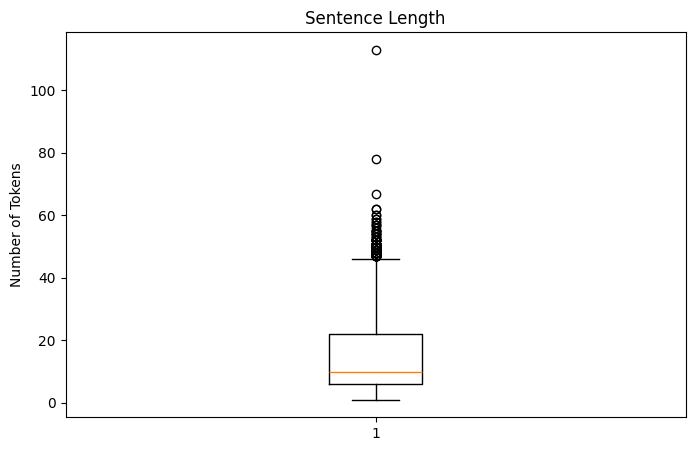

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.boxplot(sentence_lengths)
plt.title("Sentence Length")
plt.ylabel("Number of Tokens")
plt.show()

* so the majority of sentence length rests between 40:60 token

In [13]:
import numpy as np


sentence_lengths = [len(sentence) for sentence in dataset["train"]["tokens"]]
percent_95 = int(np.percentile(sentence_lengths, 95))

print(f"95th Percentile Sentence Length: {percent_95}")

95th Percentile Sentence Length: 37


* we have max lenght sentence --> 113 token
* 75% of sentence lenght -->  22 token
* 95% of sentence length --> 37 token

**Preprocesing**

* **Extracting only "Tokens" and "ner_tags" from all dataset**

In [14]:
train_tokens = dataset["train"]["tokens"]
train_labels = dataset["train"]["ner_tags"]

val_tokens = dataset["validation"]["tokens"]
val_labels = dataset["validation"]["ner_tags"]

test_tokens = dataset["test"]["tokens"]
test_labels = dataset["test"]["ner_tags"]

**Creating a vocabulary dictionary for converting tokens into sequances**

In [15]:
# counter --> to count tokens in every sentence
from collections import Counter

word_counter = Counter()

for sentence in train_tokens:
    word_counter.update(sentence)

In [16]:
# total tokens
print(len(word_counter))

23623


In [17]:
word_counter.most_common(20)

[('.', 7374),
 (',', 7290),
 ('the', 7243),
 ('of', 3751),
 ('in', 3398),
 ('to', 3382),
 ('a', 2994),
 ('(', 2861),
 (')', 2861),
 ('and', 2838),
 ('"', 2178),
 ('on', 2040),
 ('said', 1846),
 ("'s", 1536),
 ('for', 1421),
 ('1', 1421),
 ('-', 1243),
 ('The', 1127),
 ('was', 1095),
 ('2', 973)]

In [18]:
# Vocab Dictionary ---->> related with Tokenization
word2idx = {
    "<PAD>":0,
    "<OOV>":1
}

for word in word_counter:
    word2idx[word] = len(word2idx)


In [19]:
list(word2idx.items())[:10]

[('<PAD>', 0),
 ('<OOV>', 1),
 ('EU', 2),
 ('rejects', 3),
 ('German', 4),
 ('call', 5),
 ('to', 6),
 ('boycott', 7),
 ('British', 8),
 ('lamb', 9)]

**convert tokens into sequances**

In [20]:
def encode_sentences(sentences, word2idx):
    encoded_sentences = []

    for sentence in sentences:
        encoded_sentence = []

        for word in sentence:
            encoded_sentence.append(word2idx.get(word, word2idx["<OOV>"]))

        encoded_sentences.append(encoded_sentence)

    return encoded_sentences

In [21]:
X_train_seq = encode_sentences(train_tokens, word2idx)
X_valid_seq = encode_sentences(val_tokens, word2idx)
X_test_seq = encode_sentences(test_tokens, word2idx)

**Padding**

*  **Padding for "tokens"**

In [22]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_len = 43

x_train_pad= pad_sequences(
    X_train_seq,
    maxlen= max_len,
    padding= "post",
    truncating= "post"
)

x_valid_pad= pad_sequences(
    X_valid_seq,
    maxlen= max_len,
    padding= "post",
    truncating= "post"
)

x_test_pad= pad_sequences(
    X_test_seq,
    maxlen= max_len,
    padding= "post",
    truncating= "post"
)


In [23]:
print("Train Shape :", x_train_pad.shape)
print("Validation shape :", x_valid_pad.shape)
print("Test shape :", x_test_pad.shape)

Train Shape : (14041, 43)
Validation shape : (3250, 43)
Test shape : (3453, 43)


*  **Padding for "Tags" --> (Labels)**

In [60]:
y_train_pad = pad_sequences(
    train_labels,
    maxlen=max_len,
    padding="post",
    truncating="post",
    value=9
)

y_val_pad = pad_sequences(
    val_labels,
    maxlen=max_len,
    padding="post",
    truncating="post",
    value=9
)

y_test_pad = pad_sequences(
    test_labels,
    maxlen=max_len,
    padding="post",
    truncating="post",
    value=9
)

In [61]:
print(np.unique(y_train_pad))
print(np.unique(y_val_pad))
print(np.unique(y_test_pad))

[0 1 2 3 4 5 6 7 8 9]
[0 1 2 3 4 5 6 7 8 9]
[0 1 2 3 4 5 6 7 8 9]


**Embedding**

* **Glove**

In [25]:
glove_path = "/kaggle/input/datasets/abdelrahmanateff/glove-embedding/glove.6B.100d.txt"

**Embedding Matrix**

In [62]:
import numpy as np

embedding_dim = 100

embedding_matrix = np.random.normal(
    loc=0.0,
    scale=0.6,
    size=(len(word2idx), embedding_dim)
)

# pad vector --> 0
embedding_matrix[word2idx["<PAD>"]] = np.zeros(embedding_dim)

**Reading Glove File**

In [63]:
found = 0

with open(glove_path, "r", encoding="utf-8") as f:

    for line in f:

        values = line.strip().split()

        word = values[0]

        vector = np.asarray(values[1:], dtype=np.float32)

        if word in word2idx:

            embedding_matrix[word2idx[word]] = vector
            found += 1

        elif word.capitalize() in word2idx:

            embedding_matrix[word2idx[word.capitalize()]] = vector
            found += 1

        elif word.upper() in word2idx:

            embedding_matrix[word2idx[word.upper()]] = vector
            found += 1


**Coverage Percentage**

* **Total Unique Tokens coverage**

In [28]:
coverage = found / len(word2idx)

print(f"Vocabulary Size : {len(word2idx)}")
print(f"Words Found     : {found}")
print(f"Coverage        : {coverage:.2%}")

Vocabulary Size : 23625
Words Found     : 18294
Coverage        : 77.43%


* Unique Vocabulary Coverage = 77.43%

This means that 77.43% of the unique words in the training vocabulary were found in the pre-trained GloVe embeddings. The remaining 22.57% were not found, so their embeddings were randomly initialized and learned during training.

*  **Total Tokens Coverage**

In [ ]:
covered_tokens = 0
total_tokens = 0

for sentence in train_tokens:
    for word in sentence:
        total_tokens += 1

        if (
            word in glove_words
            or word.lower() in glove_words
        ):
            covered_tokens += 1

print(f"Token Coverage: {covered_tokens / total_tokens:.2%}")

* Token Coverage = 97.7%

This means that 97.7% of all word occurrences (tokens) in the training data have pre-trained GloVe embeddings. Only 2.3% of the tokens use randomly initialized embeddings.

**Saving Matrix Embedding**

In [ ]:
np.save("embedding_matrix.npy", embedding_matrix)

**Building Models**

In [32]:
import tensorflow as tf

from tensorflow.keras.models import Sequential, Model

from tensorflow.keras.layers import (
    Input,
    Embedding,
    LSTM,
    Bidirectional,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

from tensorflow.keras.optimizers import Adam

In [66]:
vocab_size = len(word2idx)
max_len = 43
embedding_dim = 100
num_classes = 10
batch_size = 64

* **LSTM**

In [67]:
# Embedding Layer

model_lstm = Sequential([

    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        input_length=max_len,
        mask_zero=True,
        trainable=True
    ),
    
  # Structure
    LSTM(128, return_sequences=True),  # to return all label tags in every sentence

    Dropout(0.3),

    Dense(num_classes,activation="softmax")

])


# ########################
# Comilation
# #######################

model_lstm.compile(

    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]

)

model_lstm.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │     2,362,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,362,500 (9.01 MB)

 Trainable params: 2,362,500 (9.01 MB)

 Non-trainable params: 0 (0.00 B)

**Callbacks**

In [68]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)


callbacks = [
    early_stop,
    reduce_lr
]

**Train & Fit**

In [69]:
###################################
#             LSTM
# ################################



checkpoint = ModelCheckpoint(
    filepath=f"../models/{model_lstm}.keras",
    monitor="val_loss",
    mode="min",
    save_best_only=True,
    verbose=1
)

history_lstm = model_lstm.fit(

    x_train_pad,
    y_train_pad,

    validation_data=(x_valid_pad, y_val_pad),
    epochs=20,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8595 - loss: 0.5326 - val_accuracy: 0.9129 - val_loss: 0.3606 - learning_rate: 0.0010
Epoch 2/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9409 - loss: 0.2142 - val_accuracy: 0.9393 - val_loss: 0.2397 - learning_rate: 0.0010
Epoch 3/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9617 - loss: 0.1367 - val_accuracy: 0.9472 - val_loss: 0.2082 - learning_rate: 0.0010
Epoch 4/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9727 - loss: 0.0965 - val_accuracy: 0.9511 - val_loss: 0.1878 - learning_rate: 0.0010
Epoch 5/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9792 - loss: 0.0719 - val_accuracy: 0.9530 - val_loss: 0.1772 - learning_rate: 0.0010
Epoch 6/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9840 - loss: 0.0543 - val_accuracy: 0.9537 - val_loss: 0.1799 - learning_rate: 0.0010
Epoch 7/20
216/220 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9879 - loss: 0.0423
E

* best epoch --> 5
* accuracy = 97.9 , val_acc = 95.3 , val_loss = 0.17

* **BILSTM**

In [70]:
# Embedding Layer

model_bilstm  = Sequential([

    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        input_length=max_len,
        mask_zero=True,
        trainable=True
    ),
    
  # Structure
    Bidirectional(
    LSTM(128, return_sequences=True)),  # to return all label tags in every sentence

    Dropout(0.3),

    Dense(num_classes,activation="softmax")

])


# ########################
# Comilation
# #######################

model_bilstm .compile(

    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]

)

model_bilstm .summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ ?                      │     2,362,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,362,500 (9.01 MB)

 Trainable params: 2,362,500 (9.01 MB)

 Non-trainable params: 0 (0.00 B)

**Train & Fit**

In [71]:
###################################
#             BILSTM
# ################################



checkpoint = ModelCheckpoint(
    filepath=f"../models/{model_bilstm}.keras",
    monitor="val_loss",
    mode="min",
    save_best_only=True,
    verbose=1
)

history_bilstm = model_bilstm.fit(

    x_train_pad,
    y_train_pad,

    validation_data=(x_valid_pad, y_val_pad),
    epochs=20,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.8756 - loss: 0.4527 - val_accuracy: 0.9261 - val_loss: 0.2723 - learning_rate: 0.0010
Epoch 2/20
216/220 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9466 - loss: 0.1863
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
220/220 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9526 - loss: 0.1652 - val_accuracy: 0.9472 - val_loss: 0.1918 - learning_rate: 0.0010
Epoch 3/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9712 - loss: 0.1020 - val_accuracy: 0.9522 - val_loss: 0.1799 - learning_rate: 5.0000e-04
Epoch 4/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9772 - loss: 0.0801 - val_accuracy: 0.9547 - val_loss: 0.1684 - learning_rate: 5.0000e-04
Epoch 5/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9819 - loss: 0.0635 - val_accuracy: 0.9573 - val_loss: 0.1603 - learning_rate: 5.0000e-04
Epoch 6/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9860

* best epoch --> 5
* accuracy = 98.1 , val_acc = 95.7 , val_loss = 0.16


In [39]:
import numpy as np

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [74]:
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

def evaluate_model(model, x_test, y_test, model_name):

    # Predict
    y_pred = model.predict(x_test, verbose=0)
    y_pred = np.argmax(y_pred, axis=-1)

    # Flatten
    y_true = y_test.flatten()
    y_pred = y_pred.flatten()

    # Remove Padding (9)
    mask = y_true != 9
    y_true = y_true[mask]
    y_pred = y_pred[mask]

    # Metrics
    acc = accuracy_score(y_true, y_pred)

    pre = precision_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    rec = recall_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    cm = confusion_matrix(y_true, y_pred)

    report = classification_report(
        y_true,
        y_pred,
        zero_division=0
    )

    return acc, pre, rec, f1, cm, report

In [75]:
lstm_acc, lstm_pre, lstm_rec, lstm_f1, lstm_cm, lstm_report = evaluate_model(
    model_lstm,
    x_test_pad,
    y_test_pad,
    "LSTM"
)

In [78]:
bilstm_acc, bilstm_pre, bilstm_rec, bilstm_f1, bilstm_cm, bilstm_report = evaluate_model(
    model_bilstm,
    x_test_pad,
    y_test_pad,
    "BILSTM"
)

In [79]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["LSTM", "BiLSTM"],
    "Test Accuracy": [lstm_acc, bilstm_acc],
    "Precision": [lstm_pre, bilstm_pre],
    "Recall": [lstm_rec, bilstm_rec],
    "F1 Score": [lstm_f1, bilstm_f1]
})

comparison = comparison.round(4)

comparison

,Model,Test Accuracy,Precision,Recall,F1 Score
0,LSTM,0.9301,0.9274,0.9301,0.9244
1,BiLSTM,0.9385,0.9361,0.9385,0.9346
